In [65]:
import src.utils as ut
import src.datasets as ds
import src.augmentation as ag
import src.hp as hp
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx, to_undirected
from torch_geometric.data import Data

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [66]:
datasplit = ds.DataSplit("power", device, 1)
data, split = datasplit.get(0)
data = ut.commu_distrib(data, 'louvain')
communities = data.communities
print("communities", communities)
print("block", data.block)
print("sizes", data.sizes)

1 split from the dataset power


100%|██████████| 1/1 [00:01<00:00,  1.33s/it]


split time:  1.33  s
data 0:  Data(edge_index=[2, 9234], id=[4941], edge_id=[13188], edge__igraph_index=[13188], citation='['D.J. Watts and S.H. Strogatz, "Collective dynamics of \'small-world\' networks." Nature 393, 440-442 (1998)., http://www.nature.com/nature/journal/v393/n6684/abs/393440a0.html']', description='A network representing the Western States Power Grid of the United States, in which nodes are transforms or power relay points and two nodes are connected if a power line runs between them.', name='power', tags='Technological, Power grid, Unweighted', url='http://www-personal.umich.edu/~mejn/netdata/', num_nodes=4941, x=[4941, 4941], adj_t=[4941, 4941, nnz=9234], max_x=-1, full_adj_t=[4941, 4941, nnz=10552])
split 0:
train edge 4617
valid edge 659
valid edge_neg 659
test edge 1318
test edge_neg 1318
communities [[18, 19, 20, 54, 64, 65, 66, 68, 69, 78, 79, 80, 105, 109, 190, 199, 933, 934, 935, 936, 937, 939, 940, 941, 942, 943, 944, 945, 946, 948, 949, 950, 951, 952, 953, 

In [67]:
G = to_networkx(data, to_undirected=True)
if hasattr(data, "_pos"):
    pos = {}
    for i, p in enumerate(data._pos):
        x, y = p.split(", ")
        pos[i] = np.array([float(x), float(y)])
else:
    pos = nx.spring_layout(G)

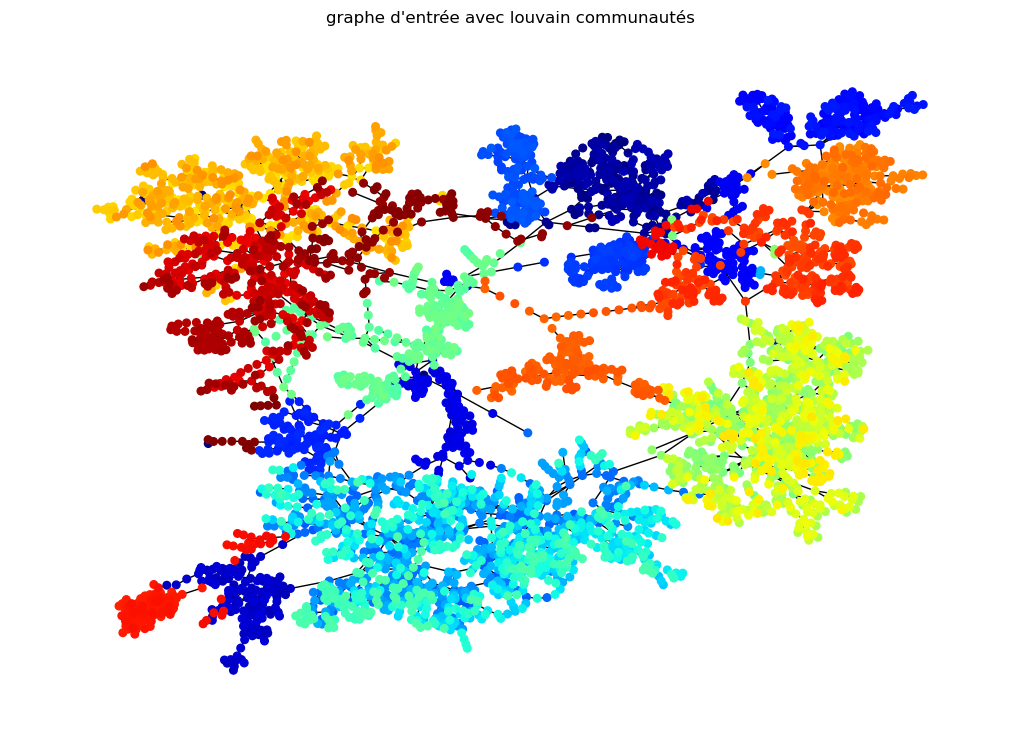

torch.Size([2, 9234])


In [68]:
def plot(data, commu, title= ""):
    G = to_networkx(data, to_undirected=True)
    color_map = {}
    # merge_small = []
    # to_remove = []
    # for i, community in enumerate(commu):
    #     if len(community) <= 5:
    #         c = commu[i]
    #         merge_small.extend(c)
    #         to_remove.append(c)
    # for r in to_remove:
    #     commu.remove(r)
    # print(len(commu))
    # commu.append(merge_small)
    # print(len(commu))
    for i, community in enumerate(commu):
        for node in community:
            color_map[node] = i
    node_colors = [color_map[node] for node in G.nodes()]
    plt.figure(figsize=(10, 7))
    nx.draw(G, node_size=30, pos=pos, node_color=node_colors, cmap=plt.cm.get_cmap('jet', len(commu)))
    # nx.draw_networkx_labels(G, pos, font_size=12, font_color='black')
    

    plt.title(title)
    plt.show()
    print(data.edge_index.shape)
commu = []
for c in range(data.num_nodes):
    commu.append([c])
plot(data, commu, "graphe d'entrée avec louvain communautés")

In [69]:
params = hp.hp_load('power', "")

....power....
no hp file, default setting load...
HYPER-PARAM: {'reconstruction_rate': 0.5, 'predp': 0.1, 'preedp': 0.1, 'lnnn': True, 'use_xlin': True, 'tailact': True, 'twolayerlin': False, 'activation': 'identity', 'skip': False, 'layer_sizes': [512, 256], 'batch_layer_norm': True, 'batchnorm_mm': 0.9, 'weight_standardization': False, 'drop_edge_rate_1': 0.3, 'drop_edge_rate_2': 0.4, 'drop_feature_rate_1': 0.1, 'drop_feature_rate_2': 0.0, 'commu_detect': 'louvain', 'ct_epochs': 100, 'proj_hidden': 32, 'gnn_lr': 0.012910226766109529, 'batch_size': 256, 'use_valedges_as_input': False, 'epochs': 100, 'loss_func': 'log_sig', 'pre_lr': 0.001230414729858406, 'mask_input': True, 'weight_decay': 1.9448284636805764e-05, 'n_layers': 2, 'hidden': 256, 'gnn_dp': 0.02, 'layer_norm': False, 'res': True, 'conv_fn': 'puregcn', 'jk': True, 'edrop': 0.55, 'xdropout': 0.66, 'taildropout': 0.41000000000000003, 'tau': 0.4}


louvain detection...


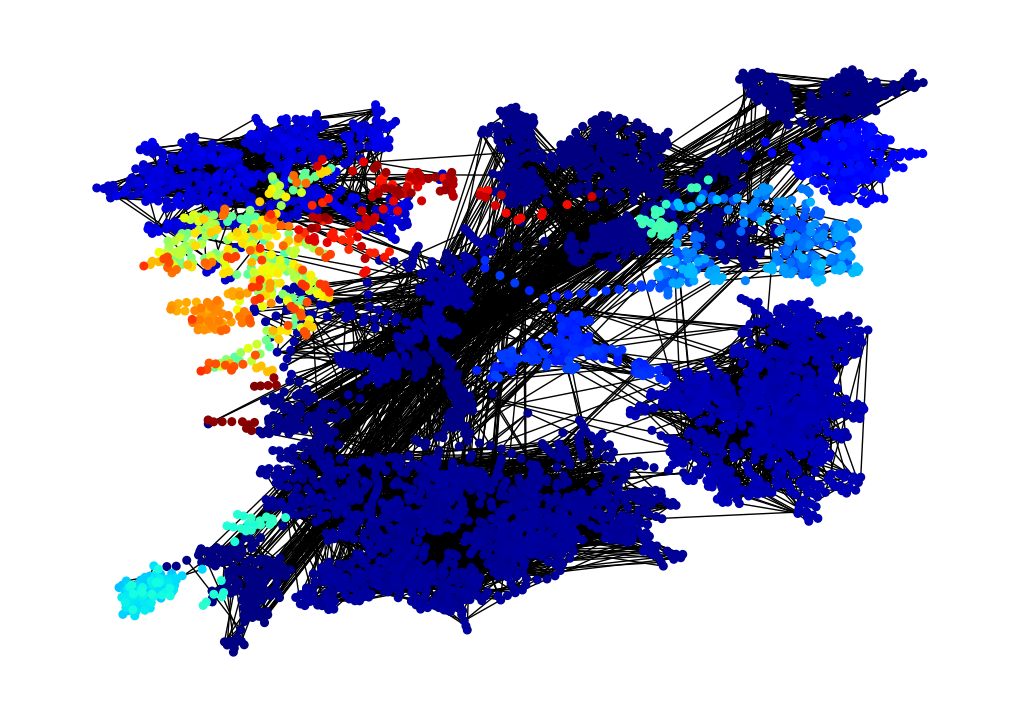

torch.Size([2, 9076])


In [70]:
aug = ag.Aug(data, split, params, 'sbm+random')
x_1, ei_1, _, _ = aug.get()
d1 = Data(x=x_1, edge_index=ei_1)
nodelist = range(sum(data.sizes))
size_cumsum = [sum(data.sizes[0:x]) for x in range(len(data.sizes) + 1)]
map_list = [
    nodelist[size_cumsum[x] : size_cumsum[x + 1]]
    for x in range(len(size_cumsum) - 1)
]
plot(d1, map_list)

louvain detection...


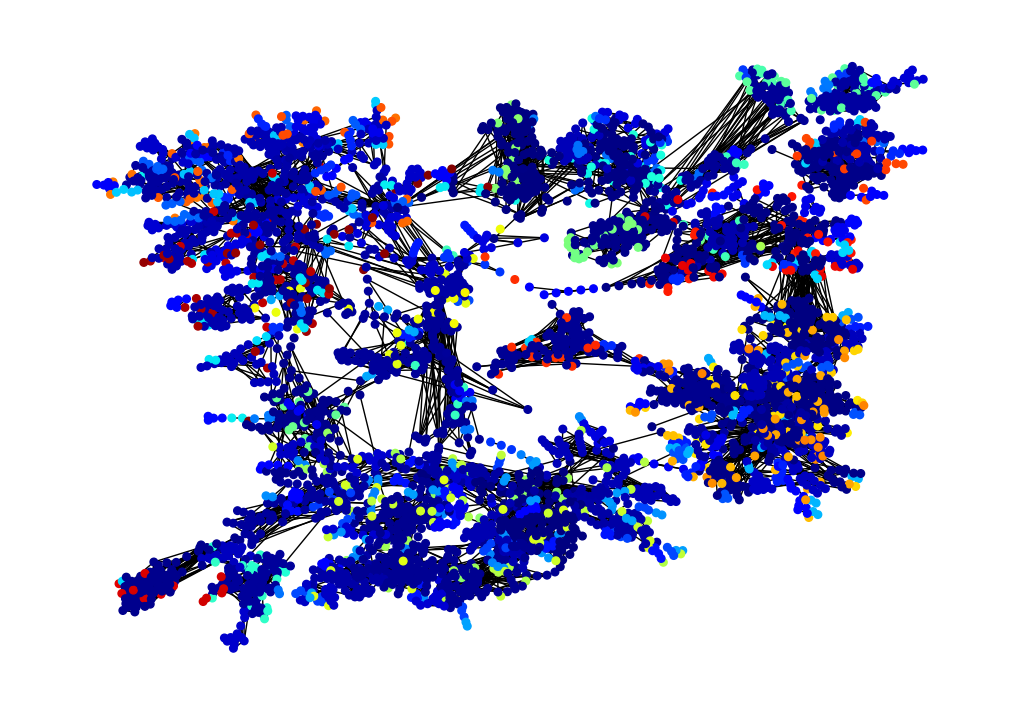

torch.Size([2, 9260])


In [71]:
aug2 = ag.Aug(data, split, params, 'sbm_fix+random')
x_1, ei_1, _, _ = aug2.get()
d2 = Data(x=x_1, edge_index=ei_1)
plot(d2, aug2.data.communities)

louvain detection...


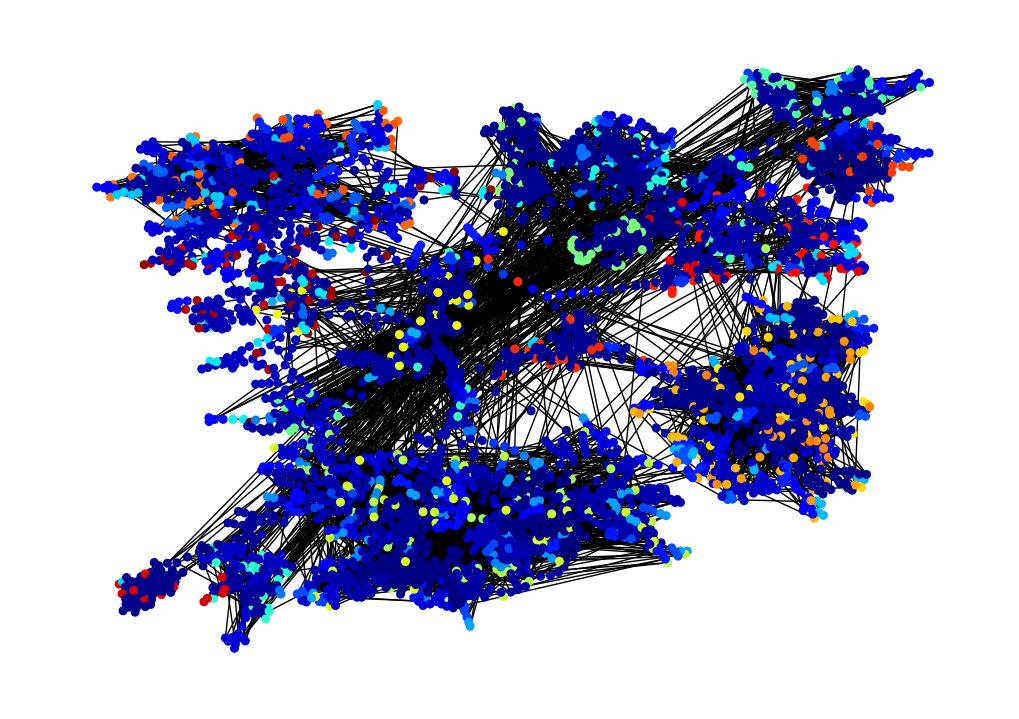

torch.Size([2, 8730])


In [77]:
aug3 = ag.Aug(data, split, params, 'sbm_fast_bug+random')
x_1, ei_1, _, _ = aug3.get()
d3 = Data(x=x_1, edge_index=ei_1)
plot(d3, aug3.data.communities)

louvain detection...


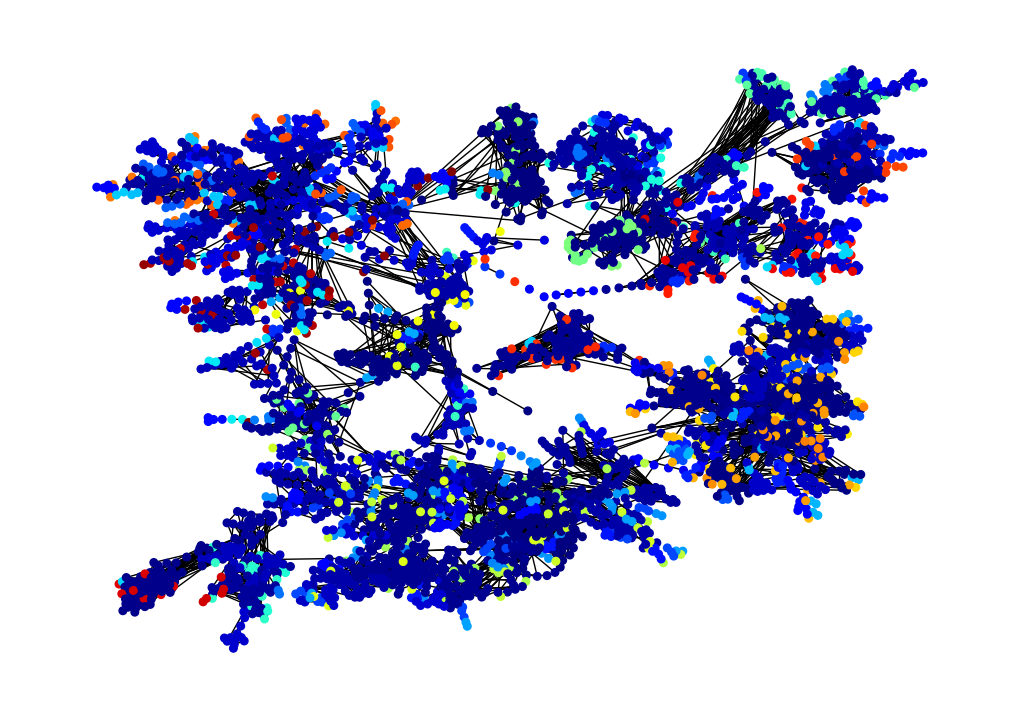

torch.Size([2, 8392])


In [78]:
aug4 = ag.Aug(data, split, params, 'sbm_fast+random')
x_1, ei_1, _, _ = aug4.get()
d4 = Data(x=x_1, edge_index=ei_1)
plot(d4, aug4.data.communities)

In [ ]:
def commu_distrib(data: Data, communities: str = None) -> Data:
    """
    detect and add community distribution

    Args:
        data (Data): input graph
        cd_algo (str, optional): algorithm. Defaults to None.

    Returns:
        Data: same Data but with commu distrib
    """
    G = to_networkx(data, to_undirected=True)
    probs = np.zeros((len(communities), len(communities)))
    sizes = []
    block = np.empty((len(G.nodes)))

    # fill block list and com attr
    for idx, c in enumerate(communities):
        sizes.append(len(c))
        for n in c:
            block[n] = idx
            G.nodes[n]["com"] = idx  # get com label
    for edge in data.edge_index.T:  # count number of edge per com
        u = float(edge[0])
        v = float(edge[1])
        if u == v:
            continue
        probs[G.nodes[u]["com"], G.nodes[v]["com"]] += 1
    for x in range(len(probs)):  # make the probs
        for y in range(len(probs)):
            if x == y:
                if sizes[x] > 1:
                    probs[x, x] = probs[x, x] / ((sizes[x] * (sizes[x] - 1)) / 2)
            else:
                probs[x, y] = probs[x, y] / (
                    ((sizes[x] + sizes[y]) * (sizes[x] + sizes[y] - 1)) / 2
                )
    probs /= 2  # undirected graph
    data.block = block
    data.communities = communities
    data.probs = probs
     # Check for probability range
    for idx, row in enumerate(probs):
        for idy, prob in enumerate(row):
            if prob < 0 or prob > 1:
                print(idx, idy, prob, sizes[x])
                raise nx.NetworkXException("Entries of 'p' not in [0,1].")
    data.sizes = sizes
    # print("probs, ", probs)
    # print("sizes, ", sizes)
    return data


d1 = commu_distrib(d1, data.communities)
d2 = commu_distrib(d2, data.communities)

In [73]:
print("bug error", np.mean((data.probs - d1.probs)))
print("normal error", np.mean((data.probs - d2.probs)))

bug error 0.00011572877253545156
normal error 3.6416657283022277e-06


In [76]:
print("bug error", np.mean((data.probs.diagonal() - d1.probs.diagonal())))
print("normal error", np.mean((data.probs.diagonal() - d2.probs.diagonal())))

bug error 0.20660109048143294
normal error 0.003109393670989091


In [74]:
print("bug error", data.probs - d1.probs)
print("normal error", data.probs - d2.probs)

bug error [[ 7.95019157e-03 -1.23548307e-05  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [-1.23548307e-05  1.31551901e-02  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  1.36705400e-02 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]]
normal error [[ 0.00038314  0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.00236382  0.         ...  0.          0.
   0.        ]
 [ 0.          0.         -0.00068353 ...  0.          0.
   0.        ]
 ...
 [ 0.          0.          0.         ...  0.          0.
   0.        ]
 [ 0.          0.          0.         ...  0